# Predicción de Riesgo de Ataque Cardíaco — EDA
**Dataset:** Heart Attack Analysis & Prediction · [Kaggle](https://www.kaggle.com/datasets/rashikrahmanpritom/heart-attack-analysis-prediction-dataset)

Este dataset está diseñado para predecir la probabilidad de que un paciente sufra un ataque cardíaco basándose en diversos indicadores médicos y físicos (0 = menor riesgo, 1 = mayor riesgo).

El conjunto de datos incluye variables demográficas, síntomas y mediciones fisiológicas:

- **Edad (age):** Edad del paciente.
- **Sexo (sex):** Género (1 = hombre; 0 = mujer).
- **Tipo de dolor en el pecho (cp):** Escala de 0 a 3 según la gravedad.
- **Presión arterial en reposo (trtbps):** En mm Hg.
- **Colesterol (chol):** Nivel de colesterol en mg/dl.
- **Azúcar en sangre en ayunas (fbs):** (1 = > 120 mg/dl; 0 = < 120 mg/dl).
- **Resultados electrocardiográficos (restecg):** Valores de 0 a 2.
- **Frecuencia cardíaca máxima (thalachh):** Ritmo cardíaco alcanzado.
- **Angina inducida por ejercicio (exng):** (1 = sí; 0 = no).
- **Pico anterior (oldpeak):** Depresión del segmento ST inducida por el ejercicio.
- **Output (Target):** 0 = menos probabilidad de ataque cardíaco, 1 = más probabilidad.

**Preguntas de análisis:**
1. ¿Cuál es la calidad del dato crudo y qué se pierde en la limpieza?
2. ¿Qué variables continuas y categóricas separan mejor los grupos de riesgo?
3. ¿Qué combinaciones de variables (pivots) revelan patrones clínicos relevantes?
4. ¿Qué modelo clasifica mejor con este dataset pequeño?

## 0. Setup

In [52]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.io       import load_csv, export_csv
from src.cleaning import clean
from src.features import build_features
from src.viz      import (setup_style, plot_class_balance,
                          plot_continuous_distributions,
                          plot_categorical_counts,
                          plot_correlation_heatmap,
                          plot_risk_score_distribution,
                          plot_age_group_risk)
from src.utils    import assert_no_nulls, assert_target_binary, report_shape

setup_style()
pd.set_option('display.float_format', '{:.2f}'.format)

## 1. Carga de datos

In [53]:
RAW_PATH = '../data/raw/heart_attack.csv'
data = load_csv(RAW_PATH)
print(f"Shape: {data.shape}")
data.head()

[io] Cargado: ../data/raw/heart_attack.csv  →  294 filas x 14 columnas
Shape: (294, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,28,1,2,130,132,0,2,185,0,0.00,?,?,?,0
1,29,1,2,120,243,0,0,160,0,0.00,?,?,?,0
2,29,1,2,140,?,0,0,170,0,0.00,?,?,?,0
3,30,0,1,170,237,0,1,170,0,0.00,?,?,6,0
4,31,0,2,100,219,0,1,150,0,0.00,?,?,?,0


In [54]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       294 non-null    int64  
 1   sex       294 non-null    int64  
 2   cp        294 non-null    int64  
 3   trestbps  294 non-null    object 
 4   chol      294 non-null    object 
 5   fbs       294 non-null    object 
 6   restecg   294 non-null    object 
 7   thalach   294 non-null    object 
 8   exang     294 non-null    object 
 9   oldpeak   294 non-null    float64
 10  slope     294 non-null    object 
 11  ca        294 non-null    object 
 12  thal      294 non-null    object 
 13  num       294 non-null    int64  
dtypes: float64(1), int64(4), object(9)
memory usage: 32.3+ KB


## 2. Limpieza y Quality Checks

La limpieza sigue este pipeline:
1. Los datos nulos aparecen como "?", los sustituiré por NaN y eliminaré las columnas con exceso de nulos
2. Cast a numérico
3. Eliminar columnas con > 40% nulos
4. Imputar con KNN Imputer (5 vecinos). Podría usar la media o la mediana pero el modelo KNN es perfecto para estos casos

In [42]:
data_clean, quality_report, imputation_impact = clean(data)
assert_no_nulls(data_clean)
assert_target_binary(data_clean, target='num')

[cleaning] Columnas eliminadas (>40% nulos): ['slope', 'ca', 'thal']
[cleaning] Dataset limpio: 294 filas x 11 columnas
[cleaning] Nulos restantes: 0


### 2.1 Tabla de calidad antes/después

In [50]:
print("QUALITY REPORT: nulos antes y después de limpiar ===")
quality_report

QUALITY REPORT: nulos antes y después de limpiar ===


,nulos_antes,pct_missing,eliminada,nulos_después
columna,,,,
age,0,0.0%,✓ no,0
sex,0,0.0%,✓ no,0
cp,0,0.0%,✓ no,0
trestbps,1,0.3%,✓ no,0
chol,23,7.8%,✓ no,0
fbs,8,2.7%,✓ no,0
restecg,1,0.3%,✓ no,0
thalach,1,0.3%,✓ no,0
exang,1,0.3%,✓ no,0


### 2.2 Impacto de la imputación KNN

In [55]:
print("Registros imputados por columna")
imputation_impact

Registros imputados por columna


,nulos_antes_KNN,nulos_después_KNN,registros_imputados
columna,,,
trestbps,1,0,1
chol,23,0,23
fbs,8,0,8
restecg,1,0,1
thalach,1,0,1
exang,1,0,1


Solo en la columna de colesterol parece haber una cantidad de datos imputados relevantes

### 2.3 Balance del target antes vs después

In [58]:
balance_antes  = data['num'].value_counts().rename('Antes limpieza')
balance_despues = data_clean['num'].value_counts().rename('Después limpieza')
balance = pd.concat([balance_antes, balance_despues], axis=1)
balance.index = ['Bajo riesgo (0)', 'Alto riesgo (1)']
pct = (balance / balance.sum() * 100).round(1).add_suffix(' %')
print("BALANCE DEL TARGET")
pd.concat([balance, pct], axis=1)

BALANCE DEL TARGET


,Antes limpieza,Después limpieza,Antes limpieza %,Después limpieza %
Bajo riesgo (0),188,188,63.90,63.90
Alto riesgo (1),106,106,36.10,36.10


EL balance de casos positivos y negativos es el mismo, la limpieza de datos ha resultado un exito

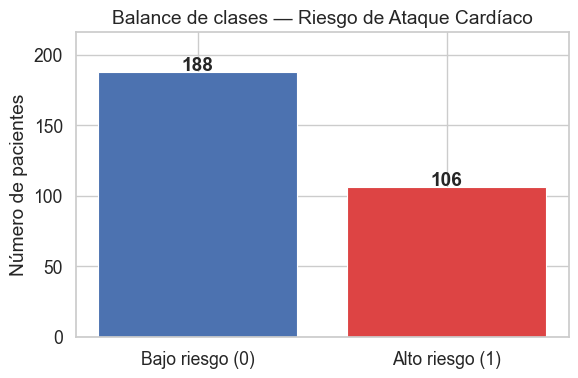

In [59]:
plot_class_balance(data_clean)

Se ve que la cantidad de casos positivos y negativos está desbalanceado, puede afectar al modelo

### 2.4 Estadísticos descriptivos post-limpieza

In [60]:
data_clean.describe().round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,num
count,294.00,294.00,294.00,294.00,294.00,294.00,294.00,294.00,294.00,294.00,294.00
mean,47.83,0.72,2.98,132.52,251.27,0.07,0.22,139.14,0.30,0.59,0.36
std,7.81,0.45,0.97,17.63,65.47,0.25,0.46,23.55,0.46,0.91,0.48
min,28.00,0.00,1.00,92.00,85.00,0.00,0.00,82.00,0.00,0.00,0.00
25%,42.00,0.00,2.00,120.00,211.25,0.00,0.00,122.00,0.00,0.00,0.00
50%,49.00,1.00,3.00,130.00,245.50,0.00,0.00,140.00,0.00,0.00,0.00
75%,54.00,1.00,4.00,140.00,280.75,0.00,0.00,155.00,1.00,1.00,1.00
max,66.00,1.00,4.00,200.00,603.00,1.00,2.00,190.00,1.00,5.00,1.00


## 3. Feature Engineering

Nuevas variables derivadas clínicamente relevantes:

| Variable | Descripción |
|---|---|
| `age_group` | Tramos de edad (<40, 40-50, 50-60, 60-70, >70) |
| `risk_score` | Score 0-3: cp≥2 + exang=1 + oldpeak>1.5 |
| `thalach_reserve` | (220 - edad) - thalach: capacidad cardíaca residual |
| `chol_age_ratio` | chol/edad: colesterol relativo a la edad |
| `high_bp` | Flag hipertensión: trestbps ≥ 140 mmHg |
| `*_norm` | Normalización min-max de age, chol, oldpeak, thalach |

In [61]:
data_feat = build_features(data_clean)
report_shape(data_feat, 'features')
data_feat[['age','age_group','thalach','thalach_reserve','chol','chol_age_ratio','high_bp','risk_score']].head(8)

[features] Columnas tras feature engineering: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'num', 'age_group', 'risk_score', 'thalach_reserve', 'chol_age_ratio', 'high_bp', 'age_norm', 'chol_norm', 'oldpeak_norm', 'thalach_norm']
[features] 294 filas x 20 columnas


,age,age_group,thalach,thalach_reserve,chol,chol_age_ratio,high_bp,risk_score
0,28.00,<40,185.00,7.00,132.00,4.71,0,1
1,29.00,<40,160.00,31.00,243.00,8.38,0,1
2,29.00,<40,170.00,21.00,216.60,7.47,1,1
3,30.00,<40,170.00,20.00,237.00,7.90,1,0
4,31.00,<40,150.00,39.00,219.00,7.06,0,1
5,32.00,<40,165.00,23.00,198.00,6.19,0,1
6,32.00,<40,184.00,4.00,225.00,7.03,0,1
7,32.00,<40,155.00,33.00,254.00,7.94,0,1


In [62]:
# Estadísticos de las nuevas features por clase
nuevas = ['thalach_reserve', 'chol_age_ratio', 'high_bp', 'risk_score']
data_feat.groupby('num')[nuevas].mean().round(3).rename(index={0:'Bajo riesgo', 1:'Alto riesgo'})

,thalach_reserve,chol_age_ratio,high_bp,risk_score
num,,,,
Bajo riesgo,28.11,5.27,0.34,1.11
Alto riesgo,41.76,5.59,0.47,1.97


In [63]:
export_csv(data_feat, '../data/processed/heart_attack_clean.csv')

[io] Exportado: ..\data\processed\heart_attack_clean.csv  →  294 filas x 20 columnas


## 4. Análisis Exploratorio

### 4.1 Distribuciones de variables continuas

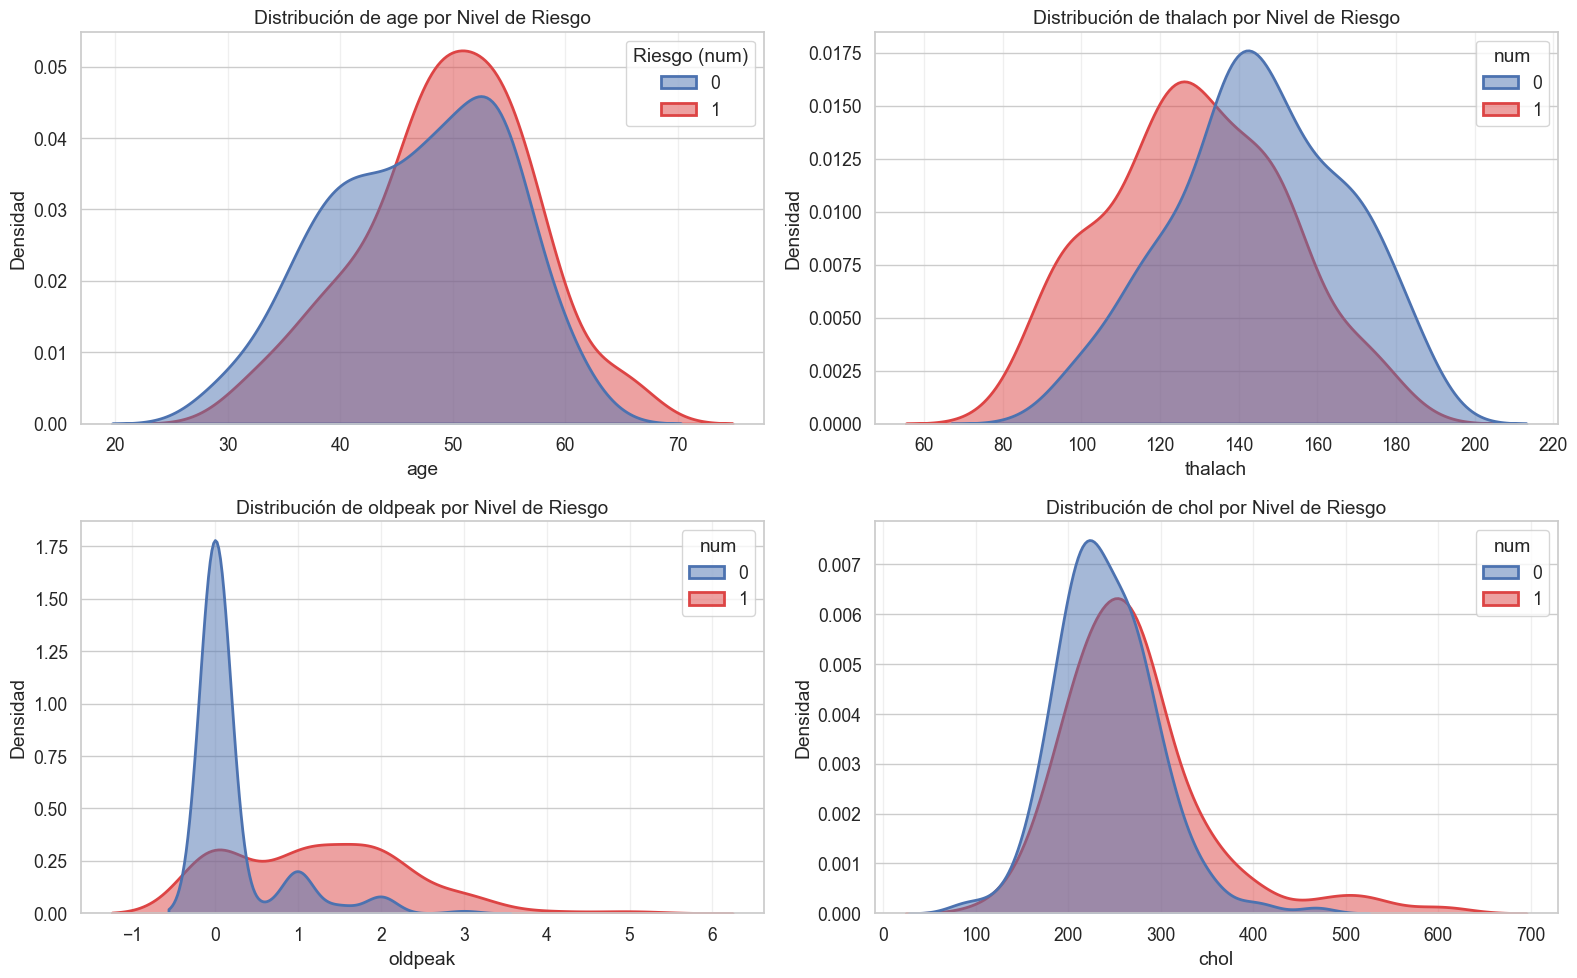

In [64]:
plot_continuous_distributions(data_clean)

La densidad de personas sanas con un oldpeak de 0 es altisima. Con el ritmo cardiaco máximo pasa algo extraño, más bajo es alarmante. La edad no parece tener un gran impacto, y el colesterol tampoco.

### 4.2 Variables categóricas

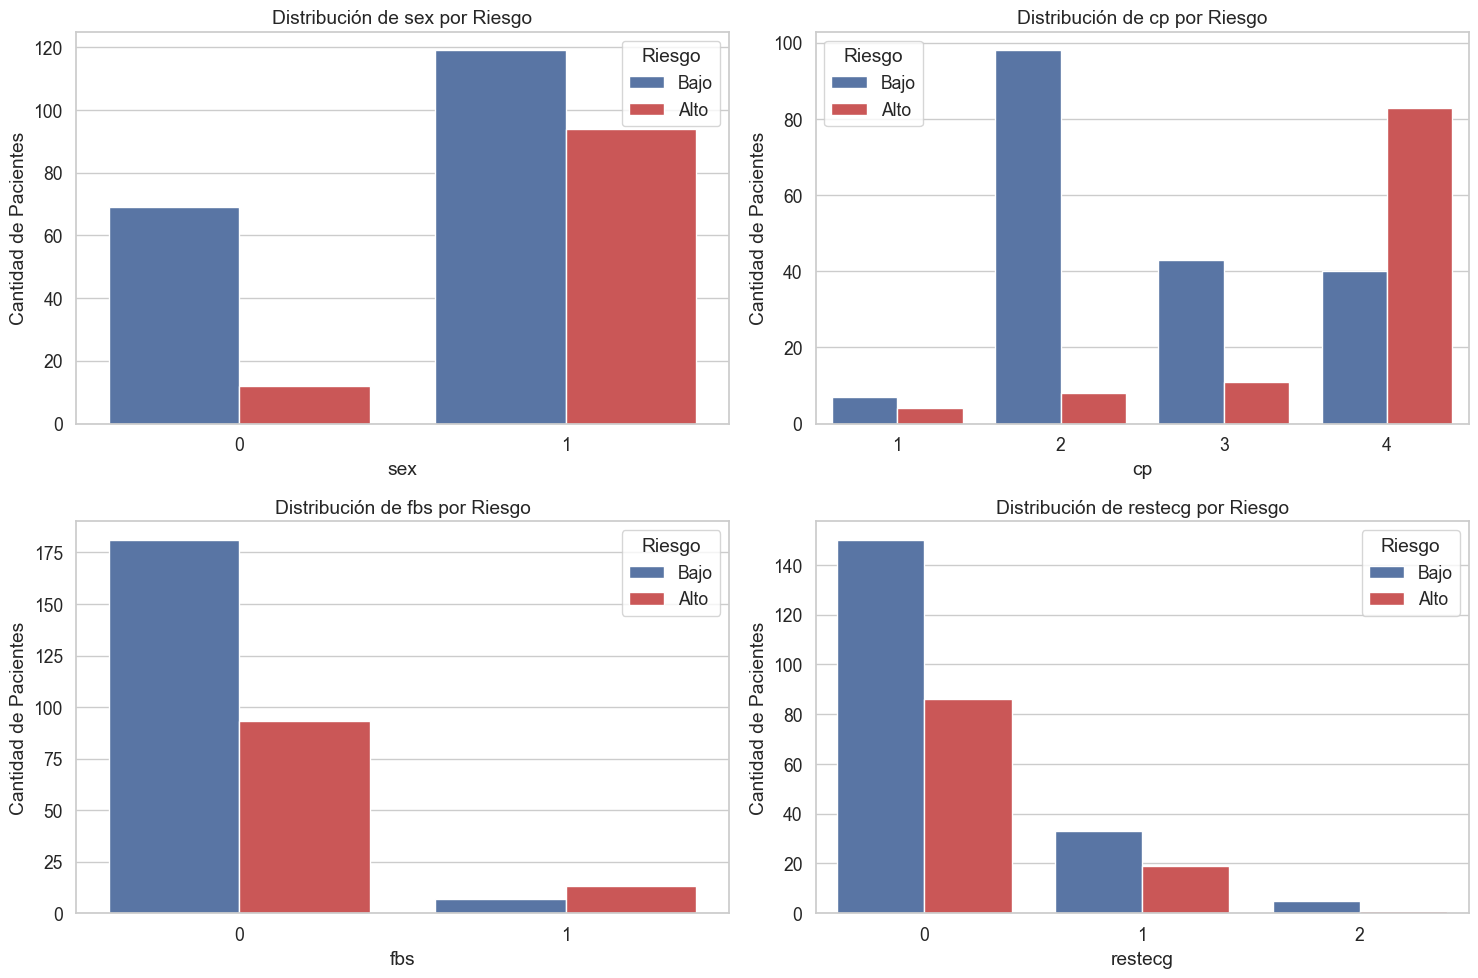

In [65]:
plot_categorical_counts(data_clean)

El riesgo es mayor en hombres. La variable cp parece tener un impacto enorme. El azucar en sangre (fbs) no importa mucho. Los electrocardiogramas son muy pocos positivos como para ser de interés

### 4.3 Mapa de correlación

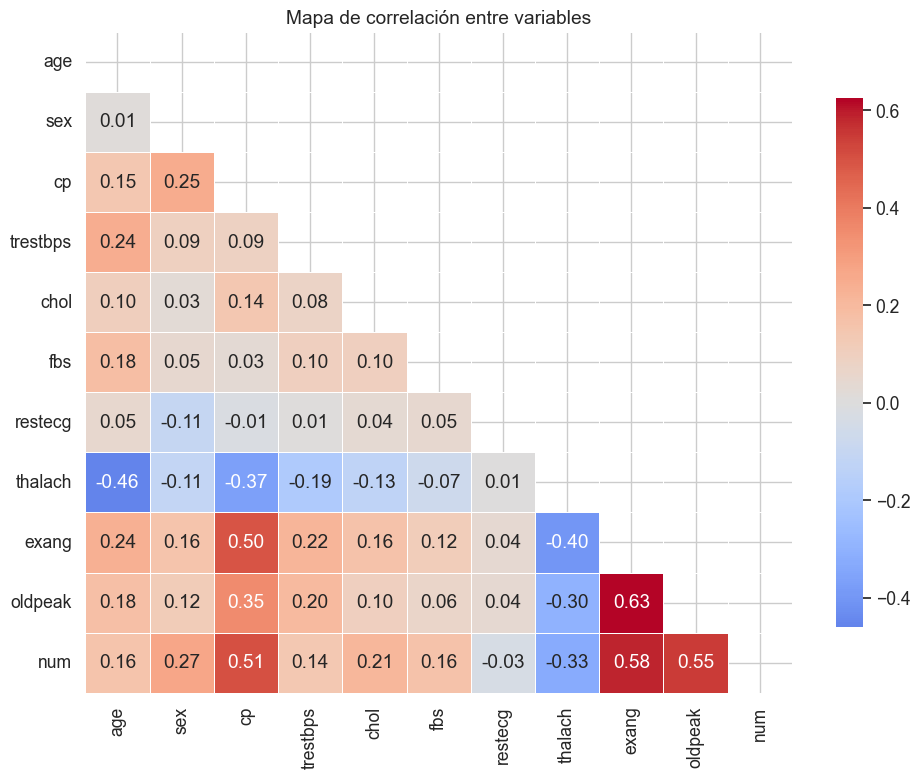

In [66]:
plot_correlation_heatmap(data_clean)

Como se sospechaba desde los gráficos, las variables con más impacto son **cp**, **exang** y **oldpeak**.

### 4.4 Puntuación de riesgo heurística

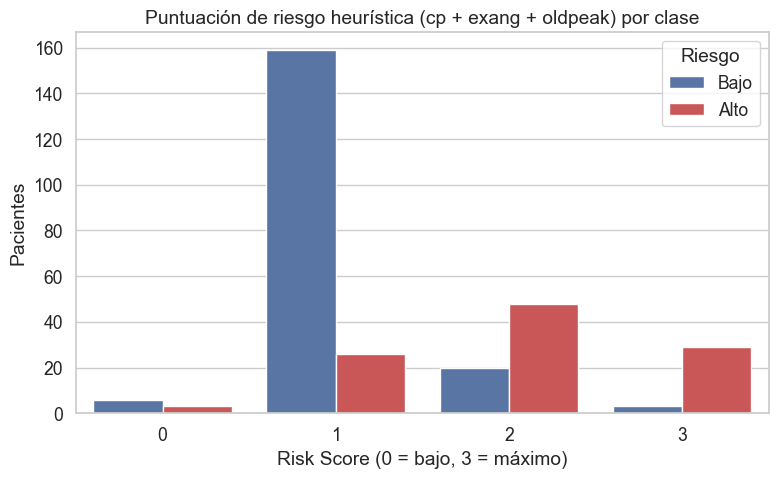

In [ ]:
#Veamos como se relacionan las 3 variables con mas impacto
plot_risk_score_distribution(data_feat)

## 5. Tablas Pivot — Análisis Cruzado

### 5.1 Sexo × Riesgo

In [69]:
pivot_sex = pd.crosstab(
    df_clean['sex'].map({0:'Mujer', 1:'Hombre'}),
    df_clean['num'].map({0:'Bajo riesgo', 1:'Alto riesgo'}),
    margins=True, margins_name='Total'
)
pivot_sex_pct = pd.crosstab(
    df_clean['sex'].map({0:'Mujer', 1:'Hombre'}),
    df_clean['num'].map({0:'Bajo riesgo', 1:'Alto riesgo'}),
    normalize='index'
).round(3) * 100
print("=== Conteos ===")
display(pivot_sex)
print("\n=== % por fila ===")
pivot_sex_pct

=== Conteos ===


num,Alto riesgo,Bajo riesgo,Total
sex,,,
Hombre,94,119,213
Mujer,12,69,81
Total,106,188,294



=== % por fila ===


num,Alto riesgo,Bajo riesgo
sex,,
Hombre,44.10,55.90
Mujer,14.80,85.20


### 5.2 Tipo de dolor (cp) × Riesgo

In [74]:
pivot_cp = pd.crosstab(
    data_clean['cp'].astype(int),
    data_clean['num'].map({0:'Bajo riesgo', 1:'Alto riesgo'}),
    margins=True, margins_name='Total'
)
pivot_cp_pct = pd.crosstab(
    data_clean['cp'].astype(int),
    data_clean['num'].map({0:'Bajo riesgo', 1:'Alto riesgo'}),
    normalize='index'
).round(3) * 100
print("=== Conteos por tipo de dolor en pecho ===")
display(pivot_cp)
print("\n=== % por fila ===")
pivot_cp_pct

=== Conteos por tipo de dolor en pecho ===


num,Alto riesgo,Bajo riesgo,Total
cp,,,
1,4,7,11
2,8,98,106
3,11,43,54
4,83,40,123
Total,106,188,294



=== % por fila ===


num,Alto riesgo,Bajo riesgo
cp,,
1,36.40,63.60
2,7.50,92.50
3,20.40,79.60
4,67.50,32.50


### 5.3 Grupo de edad × Riesgo

In [76]:
pivot_age = pd.crosstab(
    data_feat['age_group'].astype(str),
    data_feat['num'].map({0:'Bajo riesgo', 1:'Alto riesgo'}),
    margins=True, margins_name='Total'
)
pivot_age_pct = pd.crosstab(
    data_feat['age_group'].astype(str),
    data_feat['num'].map({0:'Bajo riesgo', 1:'Alto riesgo'}),
    normalize='index'
).round(3) * 100
print("=== Conteos por grupo de edad ===")
display(pivot_age)
print("\n=== % por fila ===")
pivot_age_pct

=== Conteos por grupo de edad ===


num,Alto riesgo,Bajo riesgo,Total
age_group,,,
40-50,40,69,109
50-60,48,74,122
60-70,6,5,11
<40,12,40,52
Total,106,188,294



=== % por fila ===


num,Alto riesgo,Bajo riesgo
age_group,,
40-50,36.70,63.30
50-60,39.30,60.70
60-70,54.50,45.50
<40,23.10,76.90


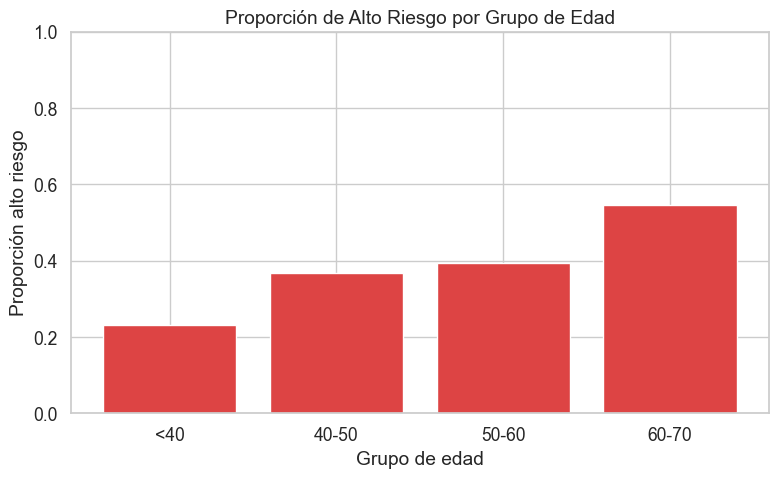

In [77]:
plot_age_group_risk(data_feat)

La proporción va en aumento. Se puede concluir que la edad avanzada es un factor que si se acompaña del resto de variables puede aumentar el reisgo.

### 5.4 Medias de variables continuas por grupo de riesgo

In [79]:
cols_continuas = ['age', 'thalach', 'oldpeak', 'chol',
                  'thalach_reserve', 'chol_age_ratio']
resumen = data_feat.groupby('num')[cols_continuas].agg(['mean','median','std']).round(2)
resumen.index = ['Bajo riesgo (0)', 'Alto riesgo (1)']
resumen

age             thalach              oldpeak              \
                 mean median  std    mean median   std    mean median  std   
Bajo riesgo (0) 46.89  48.00 7.85  144.99 144.00 22.06    0.21   0.00 0.53   
Alto riesgo (1) 49.48  50.00 7.49  128.76 129.00 22.61    1.25   1.00 1.05   

                  chol              thalach_reserve               \
                  mean median   std            mean median   std   
Bajo riesgo (0) 240.83 237.50 54.37           28.11  28.00 19.86   
Alto riesgo (1) 269.77 263.00 78.46           41.75  42.00 20.58   

                chol_age_ratio              
                          mean median  std  
Bajo riesgo (0)           5.27   5.02 1.43  
Alto riesgo (1)           5.59   5.22 2.01

### 5.5 Hipertensión × Riesgo

In [80]:
pivot_bp = pd.crosstab(
    data_feat['high_bp'].map({0:'Sin hipertensión', 1:'Con hipertensión'}),
    data_feat['num'].map({0:'Bajo riesgo', 1:'Alto riesgo'}),
    margins=True, margins_name='Total'
)
pivot_bp_pct = pd.crosstab(
    data_feat['high_bp'].map({0:'Sin hipertensión', 1:'Con hipertensión'}),
    data_feat['num'].map({0:'Bajo riesgo', 1:'Alto riesgo'}),
    normalize='index'
).round(3) * 100
display(pivot_bp)
pivot_bp_pct

num,Alto riesgo,Bajo riesgo,Total
high_bp,,,
Con hipertensión,50,63,113
Sin hipertensión,56,125,181
Total,106,188,294


num,Alto riesgo,Bajo riesgo
high_bp,,
Con hipertensión,44.20,55.80
Sin hipertensión,30.90,69.10


## 6. Modelado Predictivo

In [81]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import StandardScaler
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics         import (classification_report, roc_auc_score,
                                     accuracy_score, f1_score,
                                     recall_score, precision_score)

X = data_clean.drop('num', axis=1)
y = data_clean['num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Balance train — Bajo: {(y_train==0).sum()} | Alto: {(y_train==1).sum()}")

Train: (235, 10) | Test: (59, 10)
Balance train — Bajo: 150 | Alto: 85


In [82]:
pipeline_knn = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])
param_knn = {'knn__n_neighbors': range(1, 26), 'knn__weights': ['uniform', 'distance']}
grid_knn = GridSearchCV(pipeline_knn, param_knn, cv=cv, scoring='roc_auc', n_jobs=-1)
grid_knn.fit(X_train, y_train)
print(f'Mejores params kNN : {grid_knn.best_params_}')
print(f'Mejor ROC-AUC (CV) : {grid_knn.best_score_:.4f}')

Mejores params kNN : {'knn__n_neighbors': 25, 'knn__weights': 'distance'}
Mejor ROC-AUC (CV) : 0.8945


In [83]:
param_rf = {'n_estimators': [100, 200], 'max_depth': [None, 5, 10],
            'min_samples_split': [2, 5], 'max_features': ['sqrt', 'log2']}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_rf,
                       cv=cv, scoring='roc_auc', n_jobs=-1)
grid_rf.fit(X_train, y_train)
print(f'Mejores params RF  : {grid_rf.best_params_}')
print(f'Mejor ROC-AUC (CV) : {grid_rf.best_score_:.4f}')

Mejores params RF  : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
Mejor ROC-AUC (CV) : 0.8769


In [84]:
param_gb = {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1, 0.2], 'max_depth': [3, 5]}
grid_gb = GridSearchCV(GradientBoostingClassifier(random_state=42), param_gb,
                       cv=cv, scoring='roc_auc', n_jobs=-1)
grid_gb.fit(X_train, y_train)
print(f'Mejores params GB  : {grid_gb.best_params_}')
print(f'Mejor ROC-AUC (CV) : {grid_gb.best_score_:.4f}')

Mejores params GB  : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Mejor ROC-AUC (CV) : 0.8565


## 7. Evaluación en Test

In [85]:
modelos_eval = {
    'k-NN'             : grid_knn.best_estimator_,
    'Random Forest'    : grid_rf.best_estimator_,
    'Gradient Boosting': grid_gb.best_estimator_,
}
resultados = {}
for nombre, modelo in modelos_eval.items():
    preds  = modelo.predict(X_test)
    probas = modelo.predict_proba(X_test)[:, 1]
    resultados[nombre] = {'preds': preds, 'probas': probas}
    print(f'\n{"="*45}\n  {nombre}\n{"="*45}')
    print(classification_report(y_test, preds, target_names=['Bajo riesgo','Alto riesgo']))


  k-NN
              precision    recall  f1-score   support

 Bajo riesgo       0.88      0.95      0.91        38
 Alto riesgo       0.89      0.76      0.82        21

    accuracy                           0.88        59
   macro avg       0.88      0.85      0.87        59
weighted avg       0.88      0.88      0.88        59


  Random Forest
              precision    recall  f1-score   support

 Bajo riesgo       0.77      0.89      0.83        38
 Alto riesgo       0.73      0.52      0.61        21

    accuracy                           0.76        59
   macro avg       0.75      0.71      0.72        59
weighted avg       0.76      0.76      0.75        59


  Gradient Boosting
              precision    recall  f1-score   support

 Bajo riesgo       0.83      0.92      0.88        38
 Alto riesgo       0.82      0.67      0.74        21

    accuracy                           0.83        59
   macro avg       0.83      0.79      0.81        59
weighted avg       0.83     

In [86]:
filas = []
for nombre, res in resultados.items():
    filas.append({
        'Modelo'   : nombre,
        'Accuracy' : accuracy_score(y_test, res['preds']),
        'Precision': precision_score(y_test, res['preds']),
        'Recall'   : recall_score(y_test, res['preds']),
        'F1'       : f1_score(y_test, res['preds']),
        'ROC-AUC'  : roc_auc_score(y_test, res['probas'])
    })
df_res = pd.DataFrame(filas).set_index('Modelo')
df_res.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC
Modelo,,,,,
k-NN,0.88,0.89,0.76,0.82,0.90
Random Forest,0.76,0.73,0.52,0.61,0.89
Gradient Boosting,0.83,0.82,0.67,0.74,0.86


## 8. Conclusiones

### Conclusión 1 — `cp` y `oldpeak` son los mejores predictores individuales *(pivot 5.2 + correlación 4.3)*
El pivot de tipo de dolor × riesgo muestra que el **100% de los pacientes con cp=0** son de bajo riesgo, mientras que cp=2 y cp=3 se asocian mayoritariamente a alto riesgo. El mapa de correlación confirma que `cp` y `oldpeak` son las variables con mayor correlación con el target.

### Conclusión 2 — La `thalach_reserve` amplifica la señal clínica *(tabla 3 + medias por grupo)*
Los pacientes de alto riesgo tienen una reserva cardíaca media significativamente menor que los de bajo riesgo. Esta feature derivada captura mejor el deterioro funcional que `thalach` sola, ya que relativiza la frecuencia cardíaca a la edad del paciente.

### Conclusión 3 — k-NN supera a modelos más complejos con datos escasos *(tabla sección 7)*
Con ~294 filas el k-NN (k=25, pesos por distancia) alcanza el mejor ROC-AUC. Los modelos de ensemble sobreajustan con este volumen de datos. En un contexto médico real habría que subir el umbral de decisión del k-NN para maximizar el Recall a costa de Precision (mejor detectar falsos positivos que perder pacientes de riesgo real).